In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Introduction to Classification Trees
Classification trees represent a non-parametric supervised learning method that partitions the feature space through recursive binary splits. Each split poses a question on a single feature, directing instances along branches based on whether the condition holds true or false. This process continues until a stopping criterion is met, such as a maximum depth or minimum samples per leaf. The terminal nodes, or leaves, assign the predominant class label from the instances reaching them.

The rationale for this approach lies in its ability to model complex decision boundaries. Unlike parametric models that assume a global functional form, trees adapt locally, allowing them to approximate non-linear mappings between features $\mathbf{X}$ and labels $\mathbf{y}$. Furthermore, since splits evaluate features independently, normalisation or standardisation is unnecessary—features on disparate scales do not bias the splitting process, as thresholds are determined per feature.


## Theoretical Foundations
At each node, a classification tree selects the feature and threshold that maximise information gain or minimise impurity. Common impurity measures include the **Gini impurity** and **entropy**.

The Gini impurity for a node with $K$ classes is defined as:
$$
G = 1 - \sum_{k=1}^{K} p_k^2,
$$
where $p_k$ is the proportion of instances belonging to class $k$ in the node. A pure node (all instances of one class) has $G = 0$, while maximum impurity occurs when classes are equally distributed.

Entropy, from information theory, is:
$$
H = - \sum_{k=1}^{K} p_k \log_2 p_k,
$$
with similar properties: zero for pure nodes and maximum for uniform distributions.

Information gain for a split is the reduction in impurity:
$$
IG = I_{\text{parent}} - \left( \frac{N_{\text{left}}}{N} I_{\text{left}} + \frac{N_{\text{right}}}{N} I_{\text{right}} \right),
$$
where $I$ denotes the impurity measure, and $N_{\text{left}}$, $N_{\text{right}}$ are the sample counts in child nodes. The tree greedily chooses splits maximising $IG$, leading to hierarchical partitioning.

This recursive partitioning explains the tree's flexibility in capturing non-linearities: each split refines the decision boundary piecewise, potentially aligning with intricate data patterns. However, without constraints like maximum depth, trees may overfit by creating overly specific rules for training noise.


## Implementation in Scikit-Learn
Scikit-learn provides the `DecisionTreeClassifier` for building classification trees. The process involves data splitting, model instantiation, fitting, prediction, and evaluation.

Here is a self-contained example using a standard dataset to illustrate the syntax and workflow:

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Load a sample dataset (features and binary labels)
data = load_breast_cancer()
X = data.data[:, :2]  # Select first two features for 2D illustration
y = data.target  # Binary labels (0: malignant, 1: benign)

# Split into training and test sets (80/20, stratified for class balance)
X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.2, stratify=y, random_state=1
)

# Instantiate the classifier with constraints to prevent overfitting
classifier = DecisionTreeClassifier(max_depth=2, random_state=1)

# Fit the model to the training data
classifier.fit(X_train, y_train)

# Predict on the test set
y_pred = classifier.predict(X_test)

# Evaluate accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test set accuracy: {test_accuracy:.4f}")

Test set accuracy: 0.9035


In this code, `max_depth=2` limits the tree's complexity, promoting generalisation. The `random_state` ensures reproducibility. Stratification in splitting maintains class proportions, crucial for imbalanced datasets to avoid biased evaluation.


To visualise the tree structure:

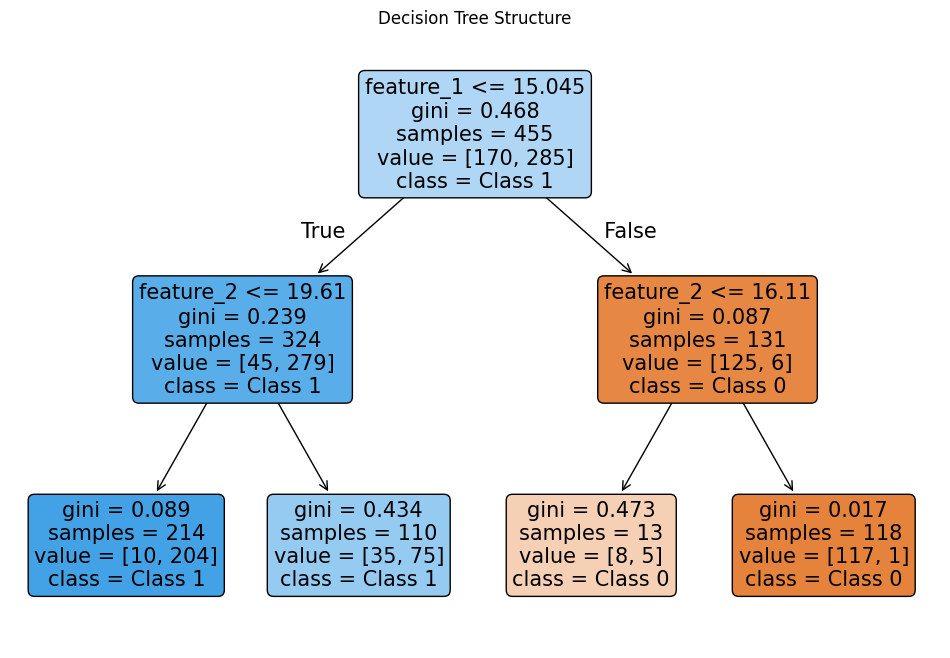

In [ ]:
from sklearn.tree import plot_tree

# Plot the decision tree
fig, ax = plt.subplots(figsize=(12, 8))
plot_tree(
	classifier,
	feature_names=["feature_1", "feature_2"],  # Generic names
	class_names=["Class 0", "Class 1"],
	filled=True,
	rounded=True,
	ax=ax,
)
ax.set_title("Decision Tree Structure")
plt.show()

This generates a diagram showing nodes, splits, and leaf predictions, mirroring the hierarchical if-else sequence.

## Decision Regions and Boundaries
A **decision region** is a subspace in the feature space where all instances are predicted to belong to the same class. These regions are delimited by **decision boundaries**, which are the hypersurfaces where the model's prediction changes.

For classification trees, decision boundaries are axis-aligned, resulting in rectangular regions because each split involves only one feature. This contrasts with smooth, often linear boundaries in other models.

To visualise decision regions, use contour plots. The following code demonstrates this using an object-oriented Seaborn approach on Matplotlib axes, comparing a tree to a linear model:

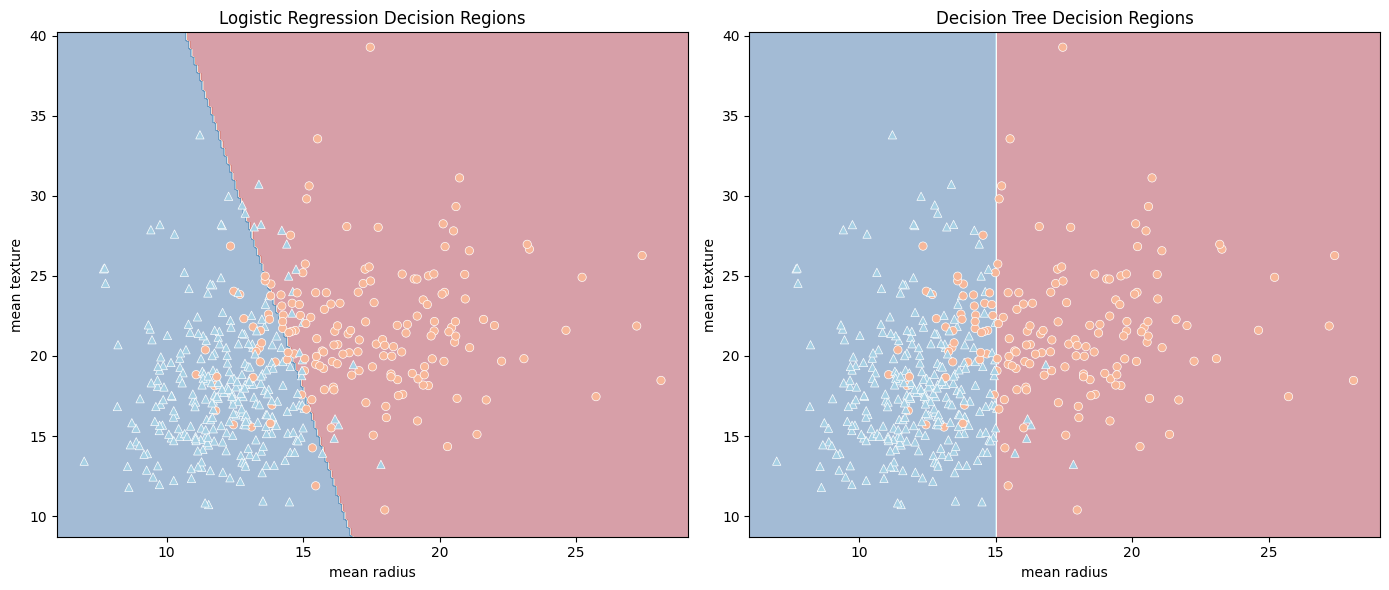

In [ ]:
from sklearn.linear_model import LogisticRegression

# Create and train logistic regression model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

# Create meshgrid for contour with reasonable step sizes
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# Predict on mesh for each model
Z_log = log_reg.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
Z_tree = classifier.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Set up figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Use actual feature names for better interpretation
feature_names = data.feature_names[:2]

# Left: Logistic Regression decision regions
axes[0].contourf(xx, yy, Z_log, alpha=0.4, cmap="RdBu")
sns.scatterplot(
	x=X_train[:, 0],
	y=X_train[:, 1],
	hue=y_train,
	palette="RdBu",
	style=y_train,
	markers=["o", "^"],
	ax=axes[0],
	legend=False,
)
axes[0].set_title("Logistic Regression Decision Regions")
axes[0].set_xlabel(feature_names[0])
axes[0].set_ylabel(feature_names[1])

# Right: Decision Tree decision regions
axes[1].contourf(xx, yy, Z_tree, alpha=0.4, cmap="RdBu")
sns.scatterplot(
	x=X_train[:, 0],
	y=X_train[:, 1],
	hue=y_train,
	palette="RdBu",
	style=y_train,
	markers=["o", "^"],
	ax=axes[1],
	legend=False,
)
axes[1].set_title("Decision Tree Decision Regions")
axes[1].set_xlabel(feature_names[0])
axes[1].set_ylabel(feature_names[1])

plt.tight_layout()
plt.show()

This plot highlights how tree boundaries are stepwise and orthogonal to axes, enabling better fit to clustered data compared to linear separators.


## Comparison with Linear Models
Linear models, such as logistic regression, assume a linear decision boundary defined by:
$$
p(y=1|\mathbf{x}) = \frac{1}{1 + e^{-\mathbf{w}^T \mathbf{x} - b}},
$$
where $\mathbf{w}$ and $b$ are learned parameters. This yields smooth, hyperplane boundaries, effective for linearly separable data but inadequate for non-linear patterns.

Classification trees, by contrast, produce piecewise constant approximations, excelling in non-linear scenarios without assuming a global form. However, trees may require ensembles (e.g., random forests) to mitigate overfitting, whereas linear models are computationally lighter and interpretable via coefficients. The choice depends on data complexity: trees for intricate relationships, linear for simplicity and speed.